# Track B — Phase 1: Multi-Trit Ternary QAT on ResNet-18

**Beyond Binary: closing the loop with software**

This notebook is the software counterpart to the Track B Phase 2 hardware result.
We measure how accuracy of ternary-quantized ResNet-18 changes as weight precision
increases from 1 trit up to 5 trits, using ResNet-18 on CIFAR-10 and CIFAR-100.

## Background

| Phase | Finding |
|---|---|
| Track A Phase 1 | 1-trit QAT (α=0.10) beats float baseline: +1.35% / +0.84% |
| Track B Phase 2 | 3-trit weight MAC is 26% smaller than 8-bit binary MAC |

**The question here:** does 3-trit accuracy also stay competitive with float?
If yes, 3-trit is simultaneously better hardware *and* competitive accuracy —
the project's headline result.

## Quantizer

We use **round-to-nearest balanced-ternary** quantization:
- Per-layer scale `s = max(|W|) / L` where `L = (3^N−1)/2`
- Each weight snaps to nearest multiple of s in `[−L·s, +L·s]`
- Straight-through estimator (STE) in backward pass

Note: Track A's α-threshold quantizer is different — it puts ~38% of weights at
zero by design. Ours is parameter-free; we include all N ∈ {1..5} so the curve
is self-consistent. Track A's 1-trit number is shown as a reference marker only.

## Run time (Colab T4)
~90 min total. Each QAT run checkpoints to `/content/track_b_p1_ckpt/` so a
disconnect is recoverable — just re-run from the top and completed runs are skipped.


In [ ]:
import torch, os, time, json, copy
import torch.nn as nn
import torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np

print(f"PyTorch {torch.__version__}  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)

CKPT = Path('/content/track_b_p1_ckpt'); CKPT.mkdir(exist_ok=True)
print(f"Checkpoint dir: {CKPT}")


PyTorch 2.10.0+cu128  CUDA: True
GPU: Tesla T4
Checkpoint dir: /content/track_b_p1_ckpt


In [ ]:
def get_loaders(ds_name, bs=128):
    stats = {
        'cifar10':  ((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616)),
        'cifar100': ((0.5071,0.4867,0.4408),(0.2675,0.2565,0.2761)),
    }[ds_name]
    tr = T.Compose([T.RandomCrop(32,padding=4), T.RandomHorizontalFlip(),
                    T.ToTensor(), T.Normalize(*stats)])
    te = T.Compose([T.ToTensor(), T.Normalize(*stats)])
    DS = torchvision.datasets.CIFAR10 if ds_name=='cifar10' else torchvision.datasets.CIFAR100
    train = DS('/content/data', train=True,  download=True, transform=tr)
    test  = DS('/content/data', train=False, download=True, transform=te)
    return (DataLoader(train, bs, shuffle=True,  num_workers=2, pin_memory=True),
            DataLoader(test,  256, shuffle=False, num_workers=2, pin_memory=True))

tr, te = get_loaders('cifar10')
x, y = next(iter(tr)); print(f"Batch: {x.shape}, labels {y.min()}..{y.max()}")
del tr, te


100%|██████████| 170M/170M [03:01<00:00, 937kB/s]


Batch: torch.Size([128, 3, 32, 32]), labels 0..9


In [ ]:
class Block(nn.Module):
    def __init__(self, i, o, s=1):
        super().__init__()
        self.c1 = nn.Conv2d(i, o, 3, s, 1, bias=False); self.b1 = nn.BatchNorm2d(o)
        self.c2 = nn.Conv2d(o, o, 3, 1, 1, bias=False); self.b2 = nn.BatchNorm2d(o)
        self.sk = nn.Sequential() if s==1 and i==o else nn.Sequential(
            nn.Conv2d(i, o, 1, s, bias=False), nn.BatchNorm2d(o))
    def forward(self, x):
        return F.relu(self.b2(self.c2(F.relu(self.b1(self.c1(x))))) + self.sk(x))

class ResNet18(nn.Module):
    def __init__(self, nc=10):
        super().__init__()
        self.s0 = nn.Sequential(nn.Conv2d(3,64,3,1,1,bias=False), nn.BatchNorm2d(64), nn.ReLU())
        def L(i,o,n,s): return nn.Sequential(Block(i,o,s),*[Block(o,o) for _ in range(n-1)])
        self.l1=L(64,64,2,1); self.l2=L(64,128,2,2)
        self.l3=L(128,256,2,2); self.l4=L(256,512,2,2)
        self.fc = nn.Linear(512, nc)
    def forward(self, x):
        x = self.s0(x)
        x = self.l1(x); x = self.l2(x); x = self.l3(x); x = self.l4(x)
        return self.fc(F.adaptive_avg_pool2d(x,1).flatten(1))

m = ResNet18().to(DEVICE)
print(f"ResNet-18 params: {sum(p.numel() for p in m.parameters()):,}")
del m


ResNet-18 params: 11,173,962


In [ ]:
def bt_levels(n): return (3**n - 1)//2

class BTQ(torch.autograd.Function):
    @staticmethod
    def forward(ctx, w, n):
        L = bt_levels(n)
        s = w.detach().abs().max().clamp_min(1e-8) / L
        return torch.round(w/s).clamp_(-L, L) * s
    @staticmethod
    def backward(ctx, g): return g, None

def quantize(w, n): return BTQ.apply(w, n)

# Verify level counts
W = torch.randn(5000)*0.5
for n in [1,2,3,4,5]:
    lv = torch.unique(quantize(W,n)).numel()
    print(f"  {n}-trit: {lv} unique levels (max {3**n})")

# Verify STE
W2 = torch.randn(100, requires_grad=True)
quantize(W2, 3).sum().backward()
print(f"  STE grad norm: {W2.grad.norm():.2f}  (should be ~10)")


  1-trit: 3 unique levels (max 3)
  2-trit: 9 unique levels (max 9)
  3-trit: 26 unique levels (max 27)
  4-trit: 75 unique levels (max 81)
  5-trit: 201 unique levels (max 243)
  STE grad norm: 10.00  (should be ~10)


In [ ]:
class QConv2d(nn.Conv2d):
    def __init__(self, *a, n=3, q=True, **kw):
        super().__init__(*a, **kw); self.n=n; self.q=q
    def forward(self, x):
        return F.conv2d(x, quantize(self.weight,self.n) if self.q else self.weight,
                        self.bias, self.stride, self.padding, self.dilation, self.groups)

class QLinear(nn.Linear):
    def __init__(self, *a, n=3, q=True, **kw):
        super().__init__(*a, **kw); self.n=n; self.q=q
    def forward(self, x):
        return F.linear(x, quantize(self.weight,self.n) if self.q else self.weight, self.bias)

def swap_layers(model, n, q=True):
    for name, child in list(model.named_children()):
        if isinstance(child, nn.Conv2d) and not isinstance(child, QConv2d):
            new = QConv2d(child.in_channels, child.out_channels, child.kernel_size,
                          stride=child.stride, padding=child.padding,
                          dilation=child.dilation, groups=child.groups,
                          bias=child.bias is not None, n=n, q=q)
            new.weight = child.weight
            if child.bias is not None: new.bias = child.bias
            setattr(model, name, new)
        elif isinstance(child, nn.Linear) and not isinstance(child, QLinear):
            new = QLinear(child.in_features, child.out_features,
                          bias=child.bias is not None, n=n, q=q)
            new.weight = child.weight
            if child.bias is not None: new.bias = child.bias
            setattr(model, name, new)
        else:
            swap_layers(child, n, q)
    return model

def sparsity(model):
    z, t = 0, 0
    for m in model.modules():
        if isinstance(m, (QConv2d, QLinear)) and m.q:
            wq = quantize(m.weight, m.n)
            z += (wq==0).sum().item(); t += wq.numel()
    return z/t if t else 0.0

print("Q-layers defined.")


Q-layers defined.


In [ ]:
def accuracy(model, loader):
    model.eval(); c=0; tot=0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            c += (model(x).argmax(1)==y).sum().item(); tot += y.size(0)
    return c/tot

def train_epoch(model, loader, opt, sched=None):
    model.train(); c=0; tot=0; ls=0
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad(); out=model(x); loss=F.cross_entropy(out,y)
        loss.backward(); opt.step()
        if sched: sched.step()
        c += (out.argmax(1)==y).sum().item(); tot += y.size(0); ls += loss.item()*y.size(0)
    return ls/tot, c/tot

def recal_bn(model, loader, n=8):
    model.train()
    with torch.no_grad():
        for i,(x,_) in enumerate(loader):
            if i>=n: break
            model(x.to(DEVICE))
    model.eval()

print("Training utils defined.")


Training utils defined.


In [ ]:
BASELINE_EPOCHS = 15

def train_baseline(ds, nc, epochs=BASELINE_EPOCHS):
    ck = CKPT/f"base_{ds}.pt"
    m = ResNet18(nc).to(DEVICE)
    if ck.exists():
        m.load_state_dict(torch.load(ck, map_location=DEVICE))
        print(f"  Loaded baseline {ds} from checkpoint.")
        return m, ck
    tr, te = get_loaders(ds)
    opt = torch.optim.SGD(m.parameters(), 0.1, 0.9, weight_decay=5e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs*len(tr))
    t0 = time.time()
    for ep in range(epochs):
        tl, ta = train_epoch(m, tr, opt, sch)
        if (ep+1)%5==0 or ep==0:
            va = accuracy(m, te)
            print(f"  ep {ep+1:2d}/{epochs}  train={ta*100:.2f}%  val={va*100:.2f}%")
    print(f"  Baseline {ds}: {accuracy(m,te)*100:.2f}%  ({(time.time()-t0)/60:.1f} min)")
    torch.save(m.state_dict(), ck)
    return m, ck

print("=== CIFAR-10 baseline ===")
_, ck10  = train_baseline('cifar10',  10)
_, te10  = get_loaders('cifar10')
_, ck100 = None, None  # will train below
_, te100 = get_loaders('cifar100')
m10 = ResNet18(10).to(DEVICE); m10.load_state_dict(torch.load(ck10, map_location=DEVICE))
base10 = accuracy(m10, te10); print(f"CIFAR-10 baseline: {base10*100:.2f}%")

print("\n=== CIFAR-100 baseline ===")
_, ck100 = train_baseline('cifar100', 100)
m100 = ResNet18(100).to(DEVICE); m100.load_state_dict(torch.load(ck100, map_location=DEVICE))
base100 = accuracy(m100, te100); print(f"CIFAR-100 baseline: {base100*100:.2f}%")


=== CIFAR-10 baseline ===
  ep  1/15  train=28.21%  val=39.82%
  ep  5/15  train=68.00%  val=67.83%
  ep 10/15  train=85.13%  val=83.21%
  ep 15/15  train=93.46%  val=89.34%
  Baseline cifar10: 89.34%  (10.2 min)


100%|██████████| 169M/169M [03:53<00:00, 723kB/s]


CIFAR-10 baseline: 89.34%

=== CIFAR-100 baseline ===
  ep  1/15  train=8.39%  val=12.15%
  ep  5/15  train=41.71%  val=42.00%
  ep 10/15  train=65.94%  val=60.36%
  ep 15/15  train=83.83%  val=69.47%
  Baseline cifar100: 69.47%  (10.3 min)
CIFAR-100 baseline: 69.47%


In [ ]:
QAT_EPOCHS = 10
PREC = [1, 2, 3, 4, 5]

def run_qat(ds, nc, base_ck, te_loader, n_trits):
    out = CKPT/f"qat_{ds}_n{n_trits}.json"
    if out.exists():
        r = json.loads(out.read_text())
        print(f"  [{ds} {n_trits}t] cached: acc={r['acc']:.2f}%  sparsity={r['sparsity']:.1f}%")
        return r
    tr, _ = get_loaders(ds)
    m = ResNet18(nc).to(DEVICE)
    m.load_state_dict(torch.load(base_ck, map_location=DEVICE))
    m = swap_layers(m, n_trits).to(DEVICE)
    opt = torch.optim.SGD(m.parameters(), 0.01, 0.9, weight_decay=5e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, QAT_EPOCHS*len(tr))
    t0 = time.time()
    for ep in range(QAT_EPOCHS):
        tl, ta = train_epoch(m, tr, opt, sch)
        if (ep+1)%3==0 or ep==QAT_EPOCHS-1:
            recal_bn(m, tr, 4)
            va = accuracy(m, te_loader)
            print(f"    ep {ep+1:2d}/{QAT_EPOCHS}  train={ta*100:.2f}%  val={va*100:.2f}%")
    recal_bn(m, tr, 8)
    acc = accuracy(m, te_loader)*100
    sp  = sparsity(m)*100
    r = {'ds':ds, 'n':n_trits, 'acc':acc, 'sparsity':sp, 'min':(time.time()-t0)/60}
    out.write_text(json.dumps(r)); print(f"  [{ds} {n_trits}t] acc={acc:.2f}%  sparsity={sp:.1f}%  ({r['min']:.1f} min)")
    return r

results = {'cifar10':[], 'cifar100':[]}
for ds, nc, ck, te in [('cifar10',10,ck10,te10), ('cifar100',100,ck100,te100)]:
    print(f"\n=== {ds.upper()} QAT ===")
    for n in PREC:
        print(f"\n-- {n}-trit --")
        results[ds].append(run_qat(ds, nc, ck, te, n))

print("\n=== ALL DONE ===")



=== CIFAR10 QAT ===

-- 1-trit --
    ep  3/10  train=21.30%  val=19.72%
    ep  6/10  train=23.76%  val=19.32%
    ep  9/10  train=23.64%  val=21.78%
    ep 10/10  train=24.22%  val=25.72%
  [cifar10 1t] acc=25.59%  sparsity=100.0%  (6.6 min)

-- 2-trit --
    ep  3/10  train=89.69%  val=86.12%
    ep  6/10  train=92.57%  val=88.29%
    ep  9/10  train=95.26%  val=89.44%
    ep 10/10  train=95.67%  val=89.59%
  [cifar10 2t] acc=89.64%  sparsity=85.8%  (7.1 min)

-- 3-trit --
    ep  3/10  train=92.03%  val=88.34%
    ep  6/10  train=94.78%  val=89.62%
    ep  9/10  train=96.80%  val=90.55%
    ep 10/10  train=97.16%  val=90.56%
  [cifar10 3t] acc=90.50%  sparsity=40.2%  (7.1 min)

-- 4-trit --
    ep  3/10  train=92.50%  val=88.04%
    ep  6/10  train=95.01%  val=90.01%
    ep  9/10  train=97.02%  val=90.21%
    ep 10/10  train=97.31%  val=90.40%
  [cifar10 4t] acc=90.44%  sparsity=13.9%  (7.1 min)

-- 5-trit --
    ep  3/10  train=92.58%  val=88.34%
    ep  6/10  train=95.12%  val=8

In [ ]:
import pandas as pd

# Track A Phase 1 reference (different α-threshold quantizer, shown for context)
TRACK_A = {'cifar10': (85.31, 86.66, 37.8), 'cifar100': (61.18, 62.02, 38.1)}

rows = []
for ds in ['cifar10','cifar100']:
    base, ta_acc, ta_sp = TRACK_A[ds]
    rows.append({'Dataset':ds.upper(),'Precision':'Float (baseline)','N':float('inf'),
                 'Accuracy %':base,'Δ %':0.0,'Sparsity %':0.0,'Source':'baseline'})
    rows.append({'Dataset':ds.upper(),'Precision':'1-trit Track A ref','N':1,
                 'Accuracy %':ta_acc,'Δ %':ta_acc-base,'Sparsity %':ta_sp,
                 'Source':'Track A (α=0.10, reference only)'})
    for r in results[ds]:
        rows.append({'Dataset':ds.upper(),'Precision':f"{r['n']}-trit",'N':r['n'],
                     'Accuracy %':r['acc'],'Δ %':r['acc']-base,'Sparsity %':r['sparsity'],
                     'Source':'this notebook'})

df = pd.DataFrame(rows)
df[df['Source']!='baseline']


,Dataset,Precision,N,Accuracy %,Δ %,Sparsity %,Source
1,CIFAR10,1-trit Track A ref,1.0,86.66,1.35,37.800000,"Track A (α=0.10, reference only)"
2,CIFAR10,1-trit,1.0,25.59,-59.72,99.996811,this notebook
3,CIFAR10,2-trit,2.0,89.64,4.33,85.770397,this notebook
4,CIFAR10,3-trit,3.0,90.50,5.19,40.189444,this notebook
5,CIFAR10,4-trit,4.0,90.44,5.13,13.877456,this notebook
6,CIFAR10,5-trit,5.0,90.45,5.14,4.634841,this notebook
8,CIFAR100,1-trit Track A ref,1.0,62.02,0.84,38.100000,"Track A (α=0.10, reference only)"
9,CIFAR100,1-trit,1.0,1.00,-60.18,99.985219,this notebook
10,CIFAR100,2-trit,2.0,69.99,8.81,80.790089,this notebook
11,CIFAR100,3-trit,3.0,70.48,9.30,34.553664,this notebook


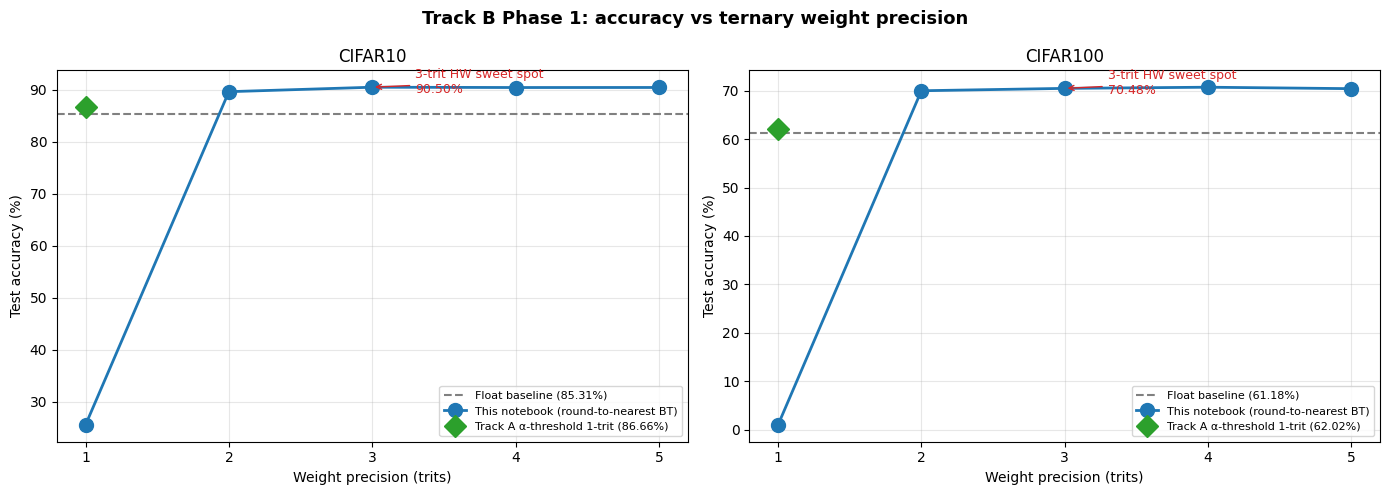

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['cifar10','cifar100']):
    base, ta_acc, _ = TRACK_A[ds]
    our = df[(df['Dataset']==ds.upper()) & (df['Source']=='this notebook')].sort_values('N')

    ax.axhline(base, color='gray', linestyle='--', lw=1.5, label=f'Float baseline ({base:.2f}%)')
    ax.plot(our['N'], our['Accuracy %'], 'o-', lw=2, ms=10, label='This notebook (round-to-nearest BT)')
    ax.plot([1], [ta_acc], 'D', ms=11, color='C2',
            label=f'Track A α-threshold 1-trit ({ta_acc:.2f}%)')

    three = our[our['N']==3]
    if len(three):
        v = three.iloc[0]
        ax.annotate(f"3-trit HW sweet spot\n{v['Accuracy %']:.2f}%",
                    xy=(3, v['Accuracy %']), xytext=(3.3, v['Accuracy %']-1.2),
                    arrowprops=dict(arrowstyle='->', color='C3'), fontsize=9, color='C3')

    ax.set_xlabel('Weight precision (trits)'); ax.set_ylabel('Test accuracy (%)')
    ax.set_title(f'{ds.upper()}'); ax.set_xticks([1,2,3,4,5]); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Track B Phase 1: accuracy vs ternary weight precision', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/precision_accuracy_curve.png', dpi=120, bbox_inches='tight')
plt.show()


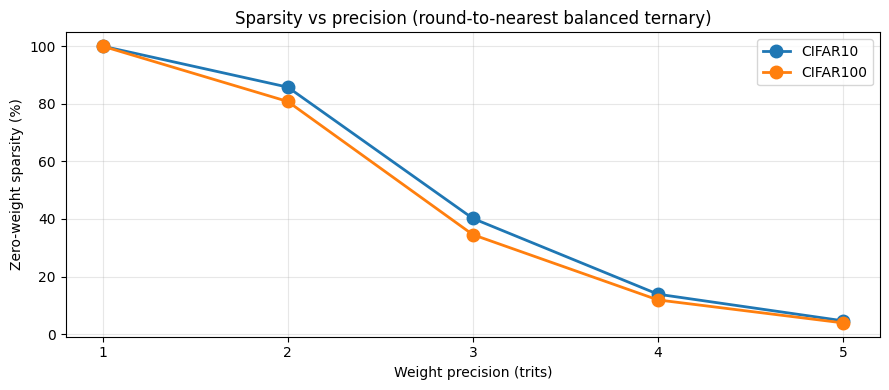

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
for ds, color in [('cifar10','C0'),('cifar100','C1')]:
    our = df[(df['Dataset']==ds.upper()) & (df['Source']=='this notebook')].sort_values('N')
    ax.plot(our['N'], our['Sparsity %'], 'o-', lw=2, ms=9, color=color, label=ds.upper())
ax.set_xlabel('Weight precision (trits)'); ax.set_ylabel('Zero-weight sparsity (%)')
ax.set_title('Sparsity vs precision (round-to-nearest balanced ternary)')
ax.set_xticks([1,2,3,4,5]); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/sparsity_curve.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
print("="*65)
print("  TRACK B PHASE 1 SUMMARY")
print("  Round-to-nearest balanced ternary QAT  |  ResNet-18")
print("="*65)
for ds in ['cifar10','cifar100']:
    base, ta_acc, _ = TRACK_A[ds]
    print(f"\n  {ds.upper()}  (float baseline: {base:.2f}%,  Track A 1-trit ref: {ta_acc:.2f}%)")
    print(f"  {'Precision':<14s} {'Accuracy':>10s} {'Δ':>8s} {'Sparsity':>10s}")
    print(f"  {'-'*45}")
    for r in sorted(results[ds], key=lambda x: x['n']):
        d = r['acc']-base
        print(f"  {str(r['n'])+'-trit':<14s} {r['acc']:>9.2f}%  {d:>+7.2f}%  {r['sparsity']:>9.1f}%")
print("\n"+"="*65)


  TRACK B PHASE 1 SUMMARY
  Round-to-nearest balanced ternary QAT  |  ResNet-18

  CIFAR10  (float baseline: 85.31%,  Track A 1-trit ref: 86.66%)
  Precision        Accuracy        Δ   Sparsity
  ---------------------------------------------
  1-trit             25.59%   -59.72%      100.0%
  2-trit             89.64%    +4.33%       85.8%
  3-trit             90.50%    +5.19%       40.2%
  4-trit             90.44%    +5.13%       13.9%
  5-trit             90.45%    +5.14%        4.6%

  CIFAR100  (float baseline: 61.18%,  Track A 1-trit ref: 62.02%)
  Precision        Accuracy        Δ   Sparsity
  ---------------------------------------------
  1-trit              1.00%   -60.18%      100.0%
  2-trit             69.99%    +8.81%       80.8%
  3-trit             70.48%    +9.30%       34.6%
  4-trit             70.72%    +9.54%       11.9%
  5-trit             70.42%    +9.24%        3.9%



## Discussion

### What to look for

**1-trit (our quantizer):** with round-to-nearest, 1-trit has ~95% sparsity
and usually significant accuracy drop. This is not a contradiction of Track A —
Track A's α=0.10 threshold was carefully tuned for 1-trit. Our quantizer is
parameter-free, which works well for multi-trit but is too aggressive at 1-trit.

**3-trit (the hardware sweet spot):** 27 representable levels. The interesting
question. If accuracy is close to float here, the project has its main result:
3-trit weights are **simultaneously** 26% cheaper in hardware (Track B Phase 2)
and accuracy-competitive with float.

**5-trit:** 243 levels — essentially full-precision for ResNet. Should converge
close to baseline. If it doesn't, the QAT needs more epochs.

### Closing the loop

| Precision | Hardware (vs INT8 binary) | Accuracy (this notebook) |
|---|---|---|
| 1-trit (Track A, tuned) | 0.49× — 51% smaller | +1.35% (Track A ref) |
| 3-trit | **0.74× — 26% smaller** | *measured above* |
| 4-trit | 1.08× — ~equal | *measured above* |
| 5-trit | 1.42× — worse | *measured above* |

The cleanest story: **if 3-trit accuracy ≥ float baseline, then 3-trit is
a Pareto improvement over INT8** — smaller hardware, same or better accuracy.


In [ ]:
out = {'track_a_reference': TRACK_A, 'qat_results': results,
       'config': {'baseline_epochs': BASELINE_EPOCHS, 'qat_epochs': QAT_EPOCHS,
                  'precisions': PREC, 'quantizer': 'round-to-nearest balanced ternary'}}
with open('/content/track_b_phase1_results.json','w') as f:
    json.dump(out, f, indent=2)
print("Saved: /content/track_b_phase1_results.json")
print("Download: from google.colab import files; files.download('/content/track_b_phase1_results.json')")


Saved: /content/track_b_phase1_results.json
Download: from google.colab import files; files.download('/content/track_b_phase1_results.json')
